Optymalny próg decyzyjny: 0.20
Maksymalny F1-score przy tym progu: 0.9863


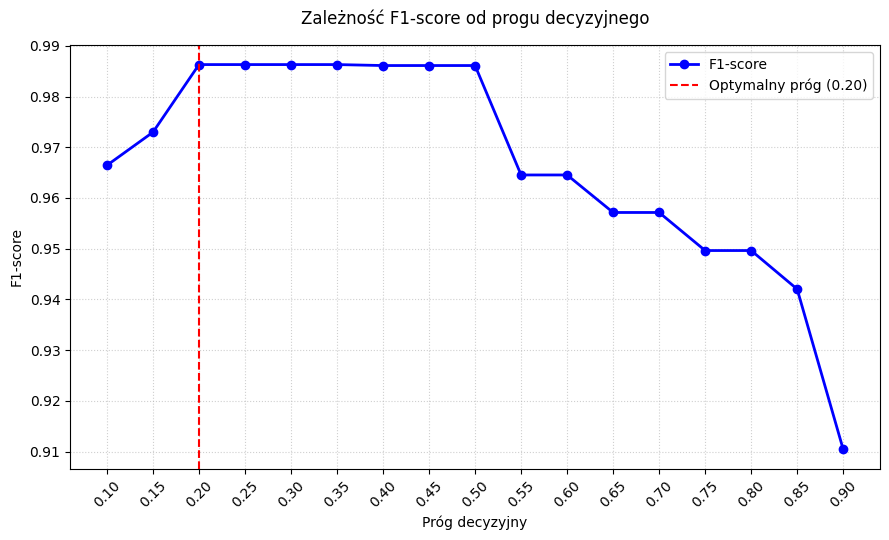

In [ ]:
# Znajdź optymalny próg decyzyjny maksymalizujący F1-score.
# Dataset:
# Breast Cancer dataset
# Wymagania:
# Testuj progi od 0.1 do 0.9 (co 0.05)
# Dla każdego progu oblicz F1-score
# Wizualizuj zależność próg → F1
# Wskaż optymalny próg
# Oczekiwany rezultat:
# Wykres progu vs F1
# Wydruk optymalnego progu

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler  # Poprawiono literówkę
from sklearn.metrics import f1_score             # Dodano brakujący import

# Przygotowanie danych
data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    #stratify, aby w obu zbiorach był taki sam procentowy udział klas (zdrowy/chory)
    data.data, data.target, test_size=0.2, random_state=42, stratify=data.target 
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Trening modelu
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# 3. Pobranie prawdopodobieństw dla klasy pozytywnej (kolumna o indeksie 1), Metoda ta zwraca prawdopodobieństwa dla obu klas
y_probs = model.predict_proba(X_test_scaled)[:, 1]

# Definicja zakresu progów od 0.1 do 0.9 co 0.05
# Używamy 0.95 jako punktu stopu, ponieważ w np.arange prawy przedział jest otwarty
thresholds = np.arange(0.1, 0.95, 0.05)
f1_scores = []

# Obliczanie F1-score dla każdego progu
for t in thresholds:
    y_pred = (y_probs >= t).astype(int)  # Ręczna klasyfikacja
    f1 = f1_score(y_test, y_pred)
    f1_scores.append(f1)

# Wyznaczenie optymalnego progu maksymalizującego F1-score
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
best_f1 = f1_scores[optimal_idx]

# Oczekiwany rezultat 1: Wydruk optymalnego progu
print(f"Optymalny próg decyzyjny: {optimal_threshold:.2f}")
print(f"Maksymalny F1-score przy tym progu: {best_f1:.4f}")

# Oczekiwany rezultat 2: Wykres progu vs F1
plt.figure(figsize=(9, 5.5))
plt.plot(thresholds, f1_scores, marker='o', color='b', linestyle='-', linewidth=2, label='F1-score')
plt.axvline(optimal_threshold, color='r', linestyle='--', label=f'Optymalny próg ({optimal_threshold:.2f})')
plt.title('Zależność F1-score od progu decyzyjnego', fontsize=12, pad=15)
plt.xlabel('Próg decyzyjny', fontsize=10)
plt.ylabel('F1-score', fontsize=10)
plt.xticks(thresholds, rotation=45)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Porównaj różne solvery regresji logistycznej pod względem czasu i dokładności.
# Wymagania:
# Przetestuj: 'lbfgs', 'liblinear', 'saga'
# Zmierz czas treningu
# Porównaj accuracy
# Oczekiwany rezultat:
# Tabela: solver | czas | accuracy
# Wnioski: który solver kiedy używać

import time
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
# Przygotowanie danych
data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
data.data, data.target, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Porównanie czasu treningu
solvers = ['lbfgs', 'liblinear', 'saga']
results = []
for solver in solvers:
    # Definicja modelu dla konkretnego solvera
    model = LogisticRegression(solver=solver, max_iter=100, random_state=42)
    print(" PORÓWNANIE CZASU TRENINGU ") # Pomiar czasu treningu
    start = time.time() 
    model.fit(X_train_scaled, y_train) # model analizuje dane pacjentów i szuka reguł.
    elapsed = time.time() - start # ile dokładnie ułamków sekundy trwał trening.
    print(f"{solver}: {elapsed:.4f}s")
#Generujemy przewidywania (tworzymy zmienną y_pred)
    y_pred = model.predict(X_test_scaled)
# Obliczanie dokładności - Accuracy
    accuracy = accuracy_score(y_test, y_pred) # Porównuje tablicę prawdziwych, historycznych diagnoz pacjentów (y_test) z odpowiedziami, które przed chwilą wygenerował model (y_pred)

# Zapisywanie wyników
    results.append({
        'solver': solver,
        'czas [s]': round(elapsed, 4),
        'accuracy': round(accuracy, 4)
    })

# Prezentacja wyników w tabeli
df_results = pd.DataFrame(results)
print("\nOczekiwany rezultat:")
print(df_results.to_string(index=False))

 PORÓWNANIE CZASU TRENINGU 
lbfgs: 0.0875s
 PORÓWNANIE CZASU TRENINGU 
liblinear: 0.0279s
 PORÓWNANIE CZASU TRENINGU 
saga: 0.1447s

Oczekiwany rezultat:
   solver  czas [s]  accuracy
    lbfgs    0.0875    0.9737
liblinear    0.0279    0.9737
     saga    0.1447    0.9912


c:\Users\Alicja\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
